# Urban Habitat Segmentation with SegFormer

This notebook trains a **Transformer-based semantic segmentation model (SegFormer)** to map urban habitat types from high-resolution aerial imagery.

Input:
- RGB orthophoto tiles (SwissImage)

Output:
- Pixel-wise habitat classes

Dataset structure:

model_ready_production/
    train/
        images/
        masks/
    val/
        images/
        masks/

Each mask contains integer class IDs.

The model is trained using **SegFormer-B2 pretrained on ImageNet**.


In [2]:
!pip install numpy==1.26.4
!pip install torch==2.2.2 torchvision==0.17.2 torchaudio==2.2.2
!pip install rasterio
!pip install segmentation-models-pytorch
!pip install torchmetrics
!pip install tqdm
!pip install matplotlib


  Using cached rasterio-1.4.4-cp311-cp311-macosx_15_0_x86_64.whl.metadata (9.3 kB)
  Using cached affine-2.4.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached attrs-25.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached certifi-2026.2.25-py3-none-any.whl.metadata (2.5 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached cligj-0.7.2-py3-none-any.whl.metadata (5.0 kB)
  Using cached click_plugins-1.1.1.2-py2.py3-none-any.whl.metadata (6.5 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached rasterio-1.4.4-cp311-cp311-macosx_15_0_x86_64.whl (25.7 MB)
Using cached click-8.3.1-py3-none-any.whl (108 kB)
Using cached cligj-0.7.2-py3-none-any.whl (7.1 kB)
Using cached affine-2.4.0-py3-none-any.whl (15 kB)
Using cached attrs-25.4.0-py3-none-any.whl (67 kB)
Using cached certifi-2026.2.25-py3-none-any.whl (153 kB)
Using cached click_plugins-1.1.1.2-py2.py3-none-any.whl (11 kB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import rasterio

import segmentation_models_pytorch as smp
from torchmetrics.classification import MulticlassJaccardIndex

from tqdm import tqdm


/Users/fadricampell/Documents/HSLU/Modules/Computer_Vision/urban-habitats-cv/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [28]:
TRAIN_IMG_DIR = "/Users/fadricampell/Documents/HSLU/Modules/Computer_Vision/urban-habitats-cv/01_data/model_ready_production/train/images"
TRAIN_MASK_DIR = "/Users/fadricampell/Documents/HSLU/Modules/Computer_Vision/urban-habitats-cv/01_data/model_ready_production/train/masks"

VAL_IMG_DIR = "/Users/fadricampell/Documents/HSLU/Modules/Computer_Vision/urban-habitats-cv/01_data/model_ready_production/val/images"
VAL_MASK_DIR = "/Users/fadricampell/Documents/HSLU/Modules/Computer_Vision/urban-habitats-cv/01_data/model_ready_production/val/masks"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BATCH_SIZE = 4
LR = 1e-4
EPOCHS = 20

PATCH_SIZE = 512
NUM_CLASSES = 8   # adjust to your dataset


In [29]:
train_images = sorted(glob.glob(os.path.join(TRAIN_IMG_DIR, "*.tif")))
train_masks = sorted(glob.glob(os.path.join(TRAIN_MASK_DIR, "*.tif")))

val_images = sorted(glob.glob(os.path.join(VAL_IMG_DIR, "*.tif")))
val_masks = sorted(glob.glob(os.path.join(VAL_MASK_DIR, "*.tif")))

print("Train tiles:", len(train_images))
print("Validation tiles:", len(val_images))


Train tiles: 3782
Validation tiles: 330


In [11]:
class HabitatDataset(Dataset):

    def __init__(self, image_paths, mask_paths):

        self.images = image_paths
        self.masks = mask_paths

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        with rasterio.open(self.images[idx]) as src:
            image = src.read([1,2,3]).transpose(1,2,0)

        with rasterio.open(self.masks[idx]) as src:
            mask = src.read(1)

        image = image.astype(np.float32) / 255.0
        mask = mask.astype(np.int64)

        image = torch.from_numpy(image).permute(2,0,1)
        mask = torch.from_numpy(mask)

        return image, mask


In [12]:
train_dataset = HabitatDataset(train_images, train_masks)
val_dataset = HabitatDataset(val_images, val_masks)

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))


Train samples: 3782
Val samples: 330


In [13]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


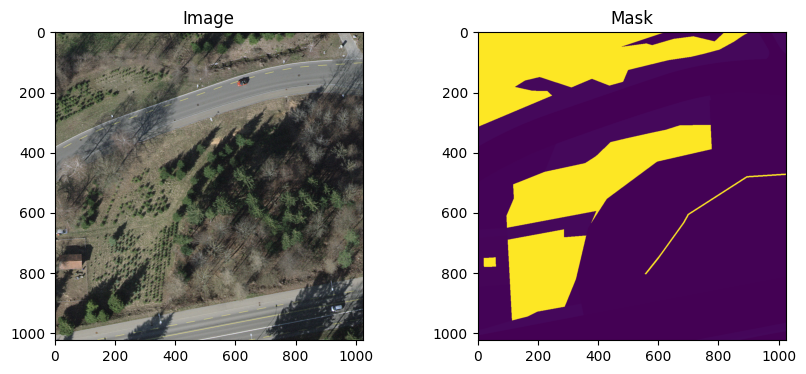

Classes: [  0   1   2   3   4   5 255]


In [20]:
img, mask = train_dataset[401]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img.permute(1,2,0))
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(mask)
plt.title("Mask")

plt.show()

print("Classes:", np.unique(mask.numpy()))


In [21]:
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES
)

model = model.to(DEVICE)


In [22]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR
)


In [23]:
iou_metric = MulticlassJaccardIndex(num_classes=NUM_CLASSES).to(DEVICE)


In [24]:
def train_epoch(loader):

    model.train()

    total_loss = 0

    for images, masks in tqdm(loader):

        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        preds = model(images)

        loss = criterion(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


In [25]:
def validate(loader):

    model.eval()

    total_loss = 0

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            preds = model(images)

            loss = criterion(preds, masks)

            preds = torch.argmax(preds, dim=1)

            iou_metric.update(preds, masks)

            total_loss += loss.item()

    iou = iou_metric.compute()

    iou_metric.reset()

    return total_loss / len(loader), iou.item()


In [26]:
train_losses = []
val_losses = []
ious = []

for epoch in range(EPOCHS):

    train_loss = train_epoch(train_loader)

    val_loss, iou = validate(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    ious.append(iou)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("Train Loss:", train_loss)
    print("Val Loss:", val_loss)
    print("mIoU:", iou)


  0%|          | 0/946 [00:10<?, ?it/s]


IndexError: Target 255 is out of bounds.

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(ious)
plt.title("Validation mIoU")

plt.show()


In [ ]:
model.eval()

img, mask = val_dataset[0]

with torch.no_grad():

    pred = model(img.unsqueeze(0).to(DEVICE))
    pred = torch.argmax(pred, dim=1).cpu().squeeze()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img.permute(1,2,0))
plt.title("Image")

plt.subplot(1,3,2)
plt.imshow(mask)
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(pred)
plt.title("Prediction")

plt.show()


In [ ]:
torch.save(model.state_dict(), "urban_habitat_unet.pth")
